In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("Device:", "MPS" if torch.backends.mps.is_available() else "CPU")

PyTorch version: 2.14.0
Device: MPS


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn

from sklearn.metrics import mean_absolute_error, mean_squared_error

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:

if torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [4]:

train_data = np.load("../data/processed/train_sequences.npz")
val_data = np.load("../data/processed/validation_sequences.npz")
test_data = np.load("../data/processed/test_sequences.npz")

X_train = train_data["X"]
y_train = train_data["y"]

X_val = val_data["X"]
y_val = val_data["y"]

X_test = test_data["X"]
y_test = test_data["y"]

print("Training:")
print("X:", X_train.shape)
print("y:", y_train.shape)

print("\nValidation:")
print("X:", X_val.shape)
print("y:", y_val.shape)

print("\nTest:")
print("X:", X_test.shape)
print("y:", y_test.shape)

Training:
X: (23973, 12, 207)
y: (23973, 207)

Validation:
X: (3410, 12, 207)
y: (3410, 207)

Test:
X: (6838, 12, 207)
y: (6838, 207)


In [5]:

scaler = joblib.load(
    "../data/processed/traffic_scaler.pkl"
)

print("Scaler loaded successfully.")

Scaler loaded successfully.


In [6]:
NUM_SENSORS = X_train.shape[2]
INPUT_STEPS = X_train.shape[1]
OUTPUT_SIZE = y_train.shape[1]

print("Number of sensors:", NUM_SENSORS)
print("Input time steps:", INPUT_STEPS)
print("Output size:", OUTPUT_SIZE)

Number of sensors: 207
Input time steps: 12
Output size: 207


In [7]:
from torch.utils.data import TensorDataset, DataLoader

X_train_tensor = torch.from_numpy(X_train).float()
y_train_tensor = torch.from_numpy(y_train).float()

X_val_tensor = torch.from_numpy(X_val).float()
y_val_tensor = torch.from_numpy(y_val).float()

X_test_tensor = torch.from_numpy(X_test).float()
y_test_tensor = torch.from_numpy(y_test).float()

print("Tensor shapes:")
print("X_train:", X_train_tensor.shape)
print("y_train:", y_train_tensor.shape)
print("X_val:", X_val_tensor.shape)
print("y_val:", y_val_tensor.shape)
print("X_test:", X_test_tensor.shape)
print("y_test:", y_test_tensor.shape)

Tensor shapes:
X_train: torch.Size([23973, 12, 207])
y_train: torch.Size([23973, 207])
X_val: torch.Size([3410, 12, 207])
y_val: torch.Size([3410, 207])
X_test: torch.Size([6838, 12, 207])
y_test: torch.Size([6838, 207])


In [8]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 375
Validation batches: 54
Test batches: 107


In [9]:
class TrafficLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=128,
        num_layers=2,
        output_size=207,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(
            hidden_size,
            output_size
        )

    def forward(self, x):


        lstm_output, (hidden_state, cell_state) = self.lstm(x)

        last_output = lstm_output[:, -1, :]

        prediction = self.fc(last_output)

        return prediction

In [10]:
model = TrafficLSTM(
    input_size=NUM_SENSORS,
    hidden_size=128,
    num_layers=2,
    output_size=OUTPUT_SIZE,
    dropout=0.2
)

model = model.to(device)

print(model)

TrafficLSTM(
  (lstm): LSTM(207, 128, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=128, out_features=207, bias=True)
)


In [11]:

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 0.001)

Loss function: MSELoss()
Optimizer: Adam
Learning rate: 0.001


In [12]:

X_batch, y_batch = next(iter(train_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    predictions = model(X_batch)

print("Input shape:", X_batch.shape)
print("Target shape:", y_batch.shape)
print("Prediction shape:", predictions.shape)

Input shape: torch.Size([64, 12, 207])
Target shape: torch.Size([64, 207])
Prediction shape: torch.Size([64, 207])


In [13]:
NUM_EPOCHS = 20

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):

    model.train()

    running_train_loss = 0.0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        predictions = model(X_batch)

        loss = criterion(predictions, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)

    model.eval()

    running_val_loss = 0.0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            predictions = model(X_batch)

            loss = criterion(predictions, y_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            model.state_dict(),
            "../models/lstm_best.pth"
        )

        best_marker = " ← best"

    else:
        best_marker = ""

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
        f"{best_marker}"
    )

Epoch 01/20 | Train Loss: 0.512658 | Val Loss: 0.489948 ← best
Epoch 02/20 | Train Loss: 0.414343 | Val Loss: 0.471222 ← best
Epoch 03/20 | Train Loss: 0.379476 | Val Loss: 0.474923
Epoch 04/20 | Train Loss: 0.357063 | Val Loss: 0.477661
Epoch 05/20 | Train Loss: 0.341881 | Val Loss: 0.477623
Epoch 06/20 | Train Loss: 0.327399 | Val Loss: 0.489818
Epoch 07/20 | Train Loss: 0.317337 | Val Loss: 0.493675
Epoch 08/20 | Train Loss: 0.309255 | Val Loss: 0.494857
Epoch 09/20 | Train Loss: 0.302355 | Val Loss: 0.495027
Epoch 10/20 | Train Loss: 0.295855 | Val Loss: 0.499853
Epoch 11/20 | Train Loss: 0.290656 | Val Loss: 0.506079
Epoch 12/20 | Train Loss: 0.286728 | Val Loss: 0.506831
Epoch 13/20 | Train Loss: 0.281780 | Val Loss: 0.507870
Epoch 14/20 | Train Loss: 0.278708 | Val Loss: 0.502405
Epoch 15/20 | Train Loss: 0.275351 | Val Loss: 0.513269
Epoch 16/20 | Train Loss: 0.272979 | Val Loss: 0.508454
Epoch 17/20 | Train Loss: 0.269401 | Val Loss: 0.513373
Epoch 18/20 | Train Loss: 0.268380

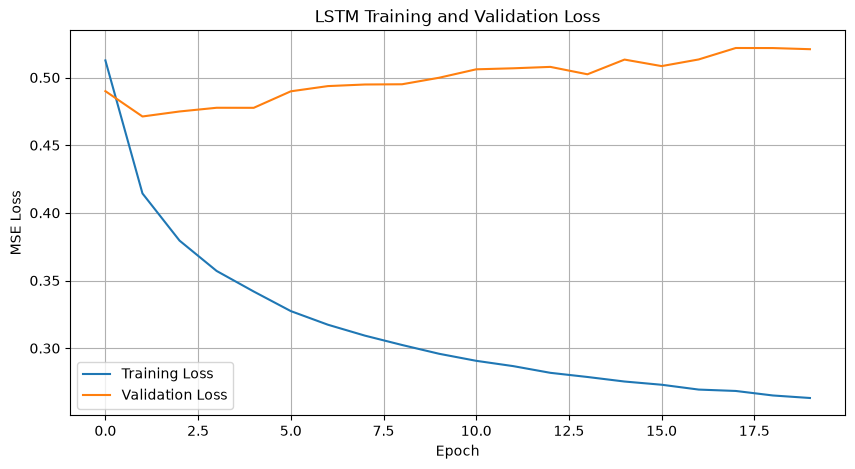

In [14]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training and Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

In [15]:

model.load_state_dict(
    torch.load(
        "../models/lstm_best.pth",
        map_location=device
    )
)

model.to(device)
model.eval()

print("Best LSTM model restored successfully.")
print("Best validation loss:", round(best_val_loss, 6))

Best LSTM model restored successfully.
Best validation loss: 0.471222


In [16]:

model.eval()

lstm_val_predictions = []

with torch.no_grad():

    for X_batch, _ in val_loader:

        X_batch = X_batch.to(device)

        predictions = model(X_batch)

        lstm_val_predictions.append(
            predictions.cpu().numpy()
        )

lstm_val_predictions = np.concatenate(
    lstm_val_predictions,
    axis=0
)

print("LSTM validation prediction shape:",
      lstm_val_predictions.shape)

print("Validation target shape:",
      y_val.shape)

LSTM validation prediction shape: (3410, 207)
Validation target shape: (3410, 207)


In [17]:

lstm_val_predictions_original = scaler.inverse_transform(
    lstm_val_predictions
)

y_val_original = scaler.inverse_transform(
    y_val
)

print(
    "Original prediction shape:",
    lstm_val_predictions_original.shape
)

print(
    "Original target shape:",
    y_val_original.shape
)

Original prediction shape: (3410, 207)
Original target shape: (3410, 207)


In [20]:

def masked_metrics(y_true, y_pred, mask):
    true_values = y_true[mask]
    pred_values = y_pred[mask]

    mae = mean_absolute_error(
        true_values,
        pred_values
    )

    rmse = np.sqrt(
        mean_squared_error(
            true_values,
            pred_values
        )
    )

    return mae, rmse


val_target_mask = np.load(
    "../data/processed/validation_target_mask.npy"
)


lstm_val_mae, lstm_val_rmse = masked_metrics(
    y_val_original,
    lstm_val_predictions_original,
    val_target_mask
)


print("LSTM - Masked Validation Results")
print("---------------------------------")
print("MAE :", round(lstm_val_mae, 4))
print("RMSE:", round(lstm_val_rmse, 4))

LSTM - Masked Validation Results
---------------------------------
MAE : 3.5952
RMSE: 6.4763


In [21]:

lstm_results = pd.DataFrame({
    "Model": ["LSTM"],
    "Validation_MAE": [lstm_val_mae],
    "Validation_RMSE": [lstm_val_rmse]
})

lstm_results.to_csv(
    "../results/lstm_validation_results.csv",
    index=False
)

print("LSTM validation results saved successfully.")

LSTM validation results saved successfully.


In [22]:

lstm_history = pd.DataFrame({
    "Epoch": range(1, len(train_losses) + 1),
    "Training_Loss": train_losses,
    "Validation_Loss": val_losses
})

lstm_history.to_csv(
    "../results/lstm_training_history.csv",
    index=False
)

print("LSTM training history saved successfully.")

LSTM training history saved successfully.
